# Regresión lineal paso a paso
### Semana 6-8 · FIA 94103 · Fundamentos de IA

Este notebook reconstruye, con datos reales de `StudentsPerformance.csv`, la matemática detrás de la regresión lineal que explica el artículo de Platzi: *¿Cuál es la matemática detrás de la regresión lineal?*

**Contenido:**
1. Exploración de los datos
2. El modelo: $y = b_0 + b_1 x$
3. Mínimos cuadrados a mano (muestra de 10 estudiantes)
4. Visualización de la recta ajustada
5. Cuantificar el error: $S_t$, $S_r$, $r^2$, $r$
6. La misma regresión sobre las 1000 filas (a mano, con NumPy)
7. Verificación con `scikit-learn`
8. Regresión múltiple: `writing ~ math + reading`
9. Análisis de residuos (supuesto de normalidad)
10. Conclusiones

## 0. Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

plt.rcParams['figure.figsize'] = (7, 5)
np.set_printoptions(precision=4, suppress=True)

## 1. Exploración de los datos

Usamos `math score` como variable independiente (x) y `reading score` como variable dependiente (y): queremos ver si la nota de matemáticas permite predecir la nota de lectura.

In [2]:
df = pd.read_csv('../StudentsPerformance.csv')
print('Filas:', len(df))
df.head()

Filas: 1000


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [3]:
df[['math score', 'reading score', 'writing score']].describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


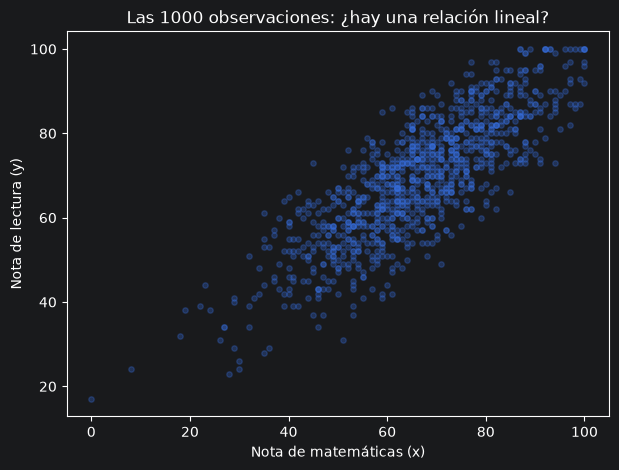

In [4]:
plt.scatter(df['math score'], df['reading score'], alpha=0.3, s=15)
plt.xlabel('Nota de matemáticas (x)')
plt.ylabel('Nota de lectura (y)')
plt.title('Las 1000 observaciones: ¿hay una relación lineal?')
plt.show()

## 2. El modelo

Buscamos la recta $\hat{y} = b_0 + b_1 x$ que mejor resume la nube de puntos. Para cada estudiante $i$, el error (residuo) es:

$$e_i = y_i - \hat{y}_i = y_i - (b_0 + b_1 x_i)$$

Hay infinitas rectas posibles; necesitamos un criterio para elegir la mejor.

## 3. Mínimos cuadrados a mano

Si sumáramos los errores tal cual, los positivos y negativos se cancelarían. Por eso se minimiza la **suma de errores al cuadrado**:

$$S_r = \sum_{i=1}^n (y_i - b_0 - b_1 x_i)^2$$

Derivando parcialmente respecto a $b_0$ y $b_1$, igualando a cero y resolviendo el sistema, se llega a:

$$b_1 = \frac{\sum (x_i-\bar{x})(y_i-\bar{y})}{\sum (x_i-\bar{x})^2} = \frac{S_{xy}}{S_{xx}} \qquad\qquad b_0 = \bar{y} - b_1 \bar{x}$$

La pendiente es *cuánto se mueven juntas x e y* (covarianza) dividido entre *cuánto se mueve x sola* (varianza de x). El intercepto obliga a la recta a pasar por el punto promedio $(\bar{x}, \bar{y})$.

Lo calculamos con una muestra pequeña (los primeros 10 estudiantes) para poder ver cada término.

In [5]:
muestra = df.head(10).copy()
x = muestra['math score'].to_numpy(dtype=float)
y = muestra['reading score'].to_numpy(dtype=float)

x_bar = x.mean()
y_bar = y.mean()
print(f'x̄ (media de math)    = {x_bar:.2f}')
print(f'ȳ (media de reading) = {y_bar:.2f}')

x̄ (media de math)    = 65.50
ȳ (media de reading) = 73.70


In [6]:
detalle = pd.DataFrame({
    'x (math)': x,
    'y (reading)': y,
    'x - x̄': x - x_bar,
    'y - ȳ': y - y_bar,
    '(x-x̄)(y-ȳ)': (x - x_bar) * (y - y_bar),
    '(x-x̄)²': (x - x_bar) ** 2,
})
detalle.round(2)

,x (math),y (reading),x - x̄,y - ȳ,(x-x̄)(y-ȳ),(x-x̄)²
0,72.0,72.0,6.5,-1.7,-11.05,42.25
1,69.0,90.0,3.5,16.3,57.05,12.25
2,90.0,95.0,24.5,21.3,521.85,600.25
3,47.0,57.0,-18.5,-16.7,308.95,342.25
4,76.0,78.0,10.5,4.3,45.15,110.25
5,71.0,83.0,5.5,9.3,51.15,30.25
6,88.0,95.0,22.5,21.3,479.25,506.25
7,40.0,43.0,-25.5,-30.7,782.85,650.25
8,64.0,64.0,-1.5,-9.7,14.55,2.25
9,38.0,60.0,-27.5,-13.7,376.75,756.25


In [7]:
S_xy = detalle['(x-x̄)(y-ȳ)'].sum()
S_xx = detalle['(x-x̄)²'].sum()

b1 = S_xy / S_xx
b0 = y_bar - b1 * x_bar

print(f'S_xy = {S_xy:.2f}')
print(f'S_xx = {S_xx:.2f}')
print(f'b1 (pendiente)  = {b1:.4f}')
print(f'b0 (intercepto) = {b0:.4f}')
print(f'\nRecta ajustada: reading ≈ {b0:.2f} + {b1:.2f} · math')

S_xy = 2626.50
S_xx = 3052.50
b1 (pendiente)  = 0.8604
b0 (intercepto) = 17.3410

Recta ajustada: reading ≈ 17.34 + 0.86 · math


## 4. Visualización de la recta ajustada

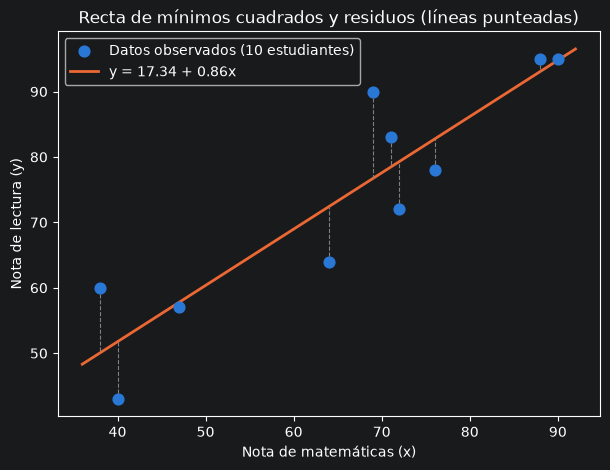

In [8]:
x_linea = np.linspace(x.min() - 2, x.max() + 2, 50)
y_linea = b0 + b1 * x_linea

plt.scatter(x, y, color='#2a78d6', s=60, label='Datos observados (10 estudiantes)', zorder=3)
plt.plot(x_linea, y_linea, color='#eb6834', linewidth=2, label=f'y = {b0:.2f} + {b1:.2f}x')
for xi, yi in zip(x, y):
    yhat = b0 + b1 * xi
    plt.plot([xi, xi], [yi, yhat], color='gray', linewidth=0.8, linestyle='--')
plt.xlabel('Nota de matemáticas (x)')
plt.ylabel('Nota de lectura (y)')
plt.title('Recta de mínimos cuadrados y residuos (líneas punteadas)')
plt.legend()
plt.show()

## 5. Cuantificar el error: $S_t$, $S_r$, $r^2$, $r$

- **$S_t$** (suma total de cuadrados): cuánto varían los datos respecto a su propia media, **sin** usar el modelo.
$$S_t = \sum (y_i - \bar{y})^2$$
- **$S_r$** (suma de cuadrados residuales): cuánto varían respecto a la recta, **usando** el modelo.
$$S_r = \sum (y_i - \hat{y}_i)^2$$

El **coeficiente de determinación**:
$$r^2 = \frac{S_t - S_r}{S_t}$$

indica qué proporción de la variabilidad de y queda explicada por el modelo. El **coeficiente de correlación** es $r = \sqrt{r^2}$.

In [9]:
y_hat = b0 + b1 * x

S_t = np.sum((y - y_bar) ** 2)
S_r = np.sum((y - y_hat) ** 2)
r2 = (S_t - S_r) / S_t
r = np.sqrt(r2)

print(f'S_t = {S_t:.2f}')
print(f'S_r = {S_r:.2f}')
print(f'r²  = {r2:.4f}  ->  el modelo explica el {r2*100:.1f}% de la variabilidad de reading')
print(f'r   = {r:.4f}')

S_t = 2784.10
S_r = 524.15
r²  = 0.8117  ->  el modelo explica el 81.2% de la variabilidad de reading
r   = 0.9010


## 6. La misma regresión sobre las 1000 filas

Con pocos puntos el ajuste "se ve" mejor de lo que es en general (es fácil sobreajustar visualmente 10 puntos). Repetimos exactamente las mismas fórmulas, ahora vectorizadas con NumPy, sobre el dataset completo.

In [10]:
def regresion_manual(x, y):
    x_bar, y_bar = x.mean(), y.mean()
    S_xy = np.sum((x - x_bar) * (y - y_bar))
    S_xx = np.sum((x - x_bar) ** 2)
    b1 = S_xy / S_xx
    b0 = y_bar - b1 * x_bar
    y_hat = b0 + b1 * x
    S_t = np.sum((y - y_bar) ** 2)
    S_r = np.sum((y - y_hat) ** 2)
    r2 = (S_t - S_r) / S_t
    return b0, b1, r2

x_full = df['math score'].to_numpy(dtype=float)
y_full = df['reading score'].to_numpy(dtype=float)

b0_full, b1_full, r2_full = regresion_manual(x_full, y_full)
print(f'Con las 1000 filas -> b0={b0_full:.4f}  b1={b1_full:.4f}  r²={r2_full:.4f}')
print(f'Con la muestra de 10 -> b0={b0:.4f}  b1={b1:.4f}  r²={r2:.4f}')
print('\nEl ajuste con 10 puntos parece mejor (r² más alto) porque una muestra chica')
print('es más fácil de "encajar" perfectamente; con más datos el r² real se estabiliza.')

Con las 1000 filas -> b0=17.1418  b1=0.7872  r²=0.6684
Con la muestra de 10 -> b0=17.3410  b1=0.8604  r²=0.8117

El ajuste con 10 puntos parece mejor (r² más alto) porque una muestra chica
es más fácil de "encajar" perfectamente; con más datos el r² real se estabiliza.


## 7. Verificación con `scikit-learn`

`LinearRegression().fit(X, y)` resuelve el mismo problema de mínimos cuadrados (internamente vía álgebra matricial), pero generaliza sin esfuerzo a más de una variable. Comprobamos que reproduce exactamente los mismos números que calculamos a mano.

In [11]:
X = x_full.reshape(-1, 1)
model = LinearRegression()
model.fit(X, y_full)
pred = model.predict(X)

print(f'b0 (intercept_) = {model.intercept_:.4f}   (manual: {b0_full:.4f})')
print(f'b1 (coef_[0])   = {model.coef_[0]:.4f}   (manual: {b1_full:.4f})')
print(f'r²              = {model.score(X, y_full):.4f}   (manual: {r2_full:.4f})')
print(f'RMSE            = {np.sqrt(mean_squared_error(y_full, pred)):.4f}')

b0 (intercept_) = 17.1418   (manual: 17.1418)
b1 (coef_[0])   = 0.7872   (manual: 0.7872)
r²              = 0.6684   (manual: 0.6684)
RMSE            = 8.4028


## 8. Regresión múltiple: `writing ~ math + reading`

Con dos variables predictoras el modelo ya no es una recta sino un plano:

$$\hat{y} = b_0 + b_1 x_1 + b_2 x_2$$

El criterio sigue siendo el mismo: minimizar $\sum (y_i - \hat{y}_i)^2$, ahora derivando respecto a $b_0, b_1, b_2$.

In [12]:
X2 = df[['math score', 'reading score']].to_numpy(dtype=float)
y2 = df['writing score'].to_numpy(dtype=float)

model2 = LinearRegression()
model2.fit(X2, y2)
pred2 = model2.predict(X2)

print(f'b0 (intercepto)      = {model2.intercept_:.4f}')
print(f'b_math               = {model2.coef_[0]:.4f}')
print(f'b_reading            = {model2.coef_[1]:.4f}')
print(f'r²                   = {model2.score(X2, y2):.4f}')
print(f'RMSE                 = {np.sqrt(mean_squared_error(y2, pred2)):.4f}')
print(f'\nEcuación: writing ≈ {model2.intercept_:.2f} + {model2.coef_[0]:.3f}·math + {model2.coef_[1]:.3f}·reading')

b0 (intercepto)      = -1.1608
b_math               = 0.0670
b_reading            = 0.9366
r²                   = 0.9127
RMSE                 = 4.4865

Ecuación: writing ≈ -1.16 + 0.067·math + 0.937·reading


**Nota de interpretación:** el peso de `reading` es mucho mayor que el de `math`. Esto no significa que matemáticas "no importe": significa que, una vez que ya conocemos la nota de lectura (muy correlacionada con escritura), la nota de matemáticas casi no agrega información nueva. Interpretar coeficientes en una regresión múltiple con predictores correlacionados entre sí requiere cuidado.

In [13]:
ejemplo = pd.DataFrame({'math score': [80], 'reading score': [85]})
pred_ejemplo = model2.predict(ejemplo.to_numpy(dtype=float))
print(f'Estudiante con math=80, reading=85 -> writing predicho = {pred_ejemplo[0]:.2f}')

Estudiante con math=80, reading=85 -> writing predicho = 83.81


## 9. Análisis de residuos

El artículo asume que los errores se distribuyen aproximadamente normal alrededor de la recta, con magnitud similar en todo el rango de x (homocedasticidad). Lo comprobamos visualmente sobre la regresión múltiple.

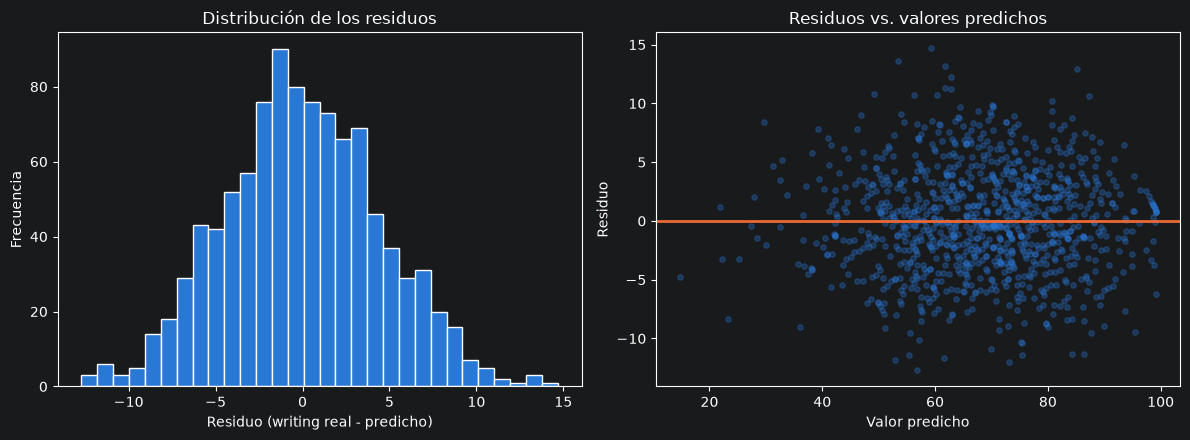

Media de residuos  ≈ -0.0000  (debería ser ~0)
Desv. estándar     = 4.4865


In [14]:
residuos = y2 - pred2

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(residuos, bins=30, color='#2a78d6', edgecolor='white')
axes[0].set_title('Distribución de los residuos')
axes[0].set_xlabel('Residuo (writing real - predicho)')
axes[0].set_ylabel('Frecuencia')

axes[1].scatter(pred2, residuos, alpha=0.3, s=15, color='#2a78d6')
axes[1].axhline(0, color='#eb6834', linewidth=2)
axes[1].set_title('Residuos vs. valores predichos')
axes[1].set_xlabel('Valor predicho')
axes[1].set_ylabel('Residuo')

plt.tight_layout()
plt.show()

print(f'Media de residuos  ≈ {residuos.mean():.4f}  (debería ser ~0)')
print(f'Desv. estándar     = {residuos.std():.4f}')

Si el histograma se ve razonablemente acampanado y la nube de "residuos vs. predichos" no muestra un embudo (varianza creciente) ni una curva, el supuesto de errores normales y de magnitud similar se sostiene razonablemente bien.

## 10. Conclusiones

- La regresión lineal simple busca la recta que minimiza la suma de errores al cuadrado; sus parámetros tienen fórmula cerrada a partir de covarianza y varianza.
- $r^2$ cuantifica qué fracción de la variabilidad de y explica el modelo: aquí, `math` explica ~67% de `reading`, pero `math + reading` juntos explican ~91% de `writing`.
- El tamaño de muestra importa: con 10 puntos el ajuste parece mejor de lo que realmente es sobre la población completa.
- `scikit-learn` reproduce exactamente el cálculo manual — la ventaja de la librería es escalar a más variables y evitar errores de cómputo, no cambiar la matemática de fondo.
- En una regresión múltiple, un coeficiente pequeño no implica que la variable "no importe"; puede significar que su información ya está capturada por otro predictor correlacionado.